<a href="https://colab.research.google.com/github/disha526/EDA-Telecom-Churn-Dataset/blob/main/Practicals_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Correlation

In [ ]:
import pandas as pd

data = {'Hours': [2,4,5,7,9], 'Marks': [40,55,65,80,95]}
df   = pd.DataFrame(data)

corr = df['Hours'].corr(df['Marks'])
print(corr)   # value b/w -1 and +1

0.9992979794987213


In [ ]:
corr = df['Hours'].corr(df['Marks'], method='spearman')

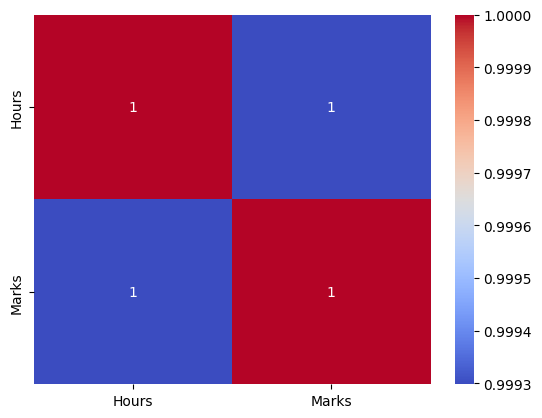

In [ ]:
import seaborn as sns

corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

## Line plot — trend over time

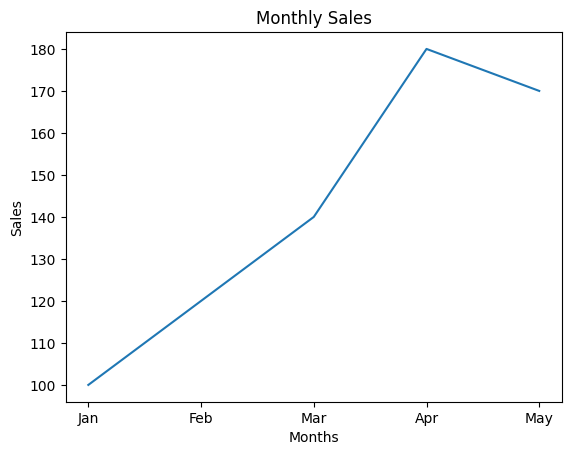

In [ ]:
import matplotlib.pyplot as plt

months = ["Jan","Feb","Mar","Apr","May"]
sales  = [100, 120, 140, 180, 170]

plt.plot(months, sales)
plt.title("Monthly Sales")
plt.xlabel("Months")
plt.ylabel("Sales")
plt.show()

## Bar chart — compare categories

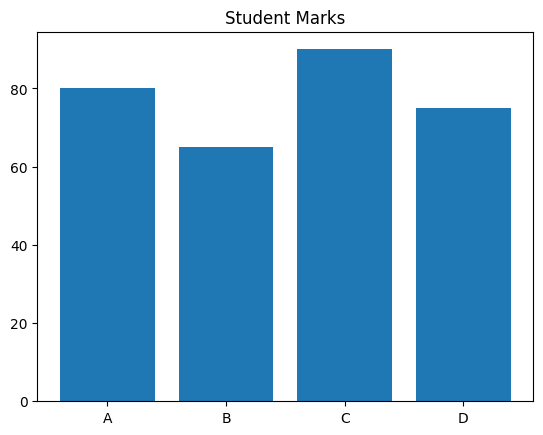

In [ ]:
students = ["A","B","C","D"]
marks    = [80, 65, 90, 75]

plt.bar(students, marks)
plt.title("Student Marks")
plt.show()

## Histogram — distribution

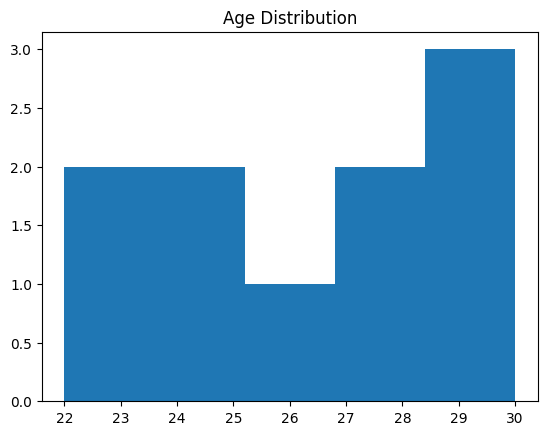

In [ ]:
ages = [22,23,24,25,26,27,28,29,30,30]

plt.hist(ages, bins=5)
plt.title("Age Distribution")
plt.show()

## Scatter plot — correlation

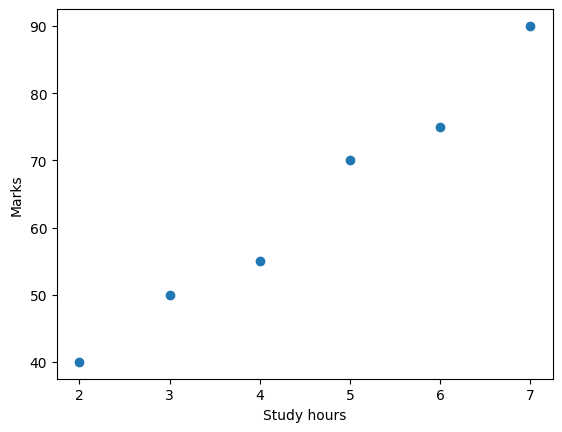

In [ ]:
hours = [2,3,4,5,6,7]
marks = [40,50,55,70,75,90]

plt.scatter(hours, marks)
plt.xlabel("Study hours")
plt.ylabel("Marks")
plt.show()

## Pie chart — percentage share

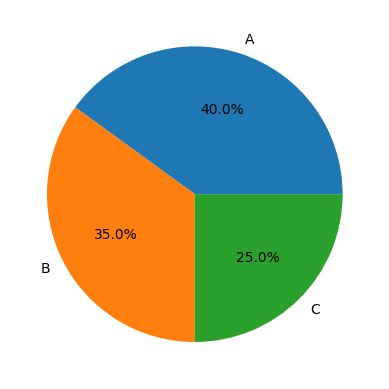

In [ ]:
companies = ["A","B","C"]
share     = [40, 35, 25]

plt.pie(share, labels=companies, autopct='%1.1f%%')
plt.show()

## Seaborn histogram with KDE

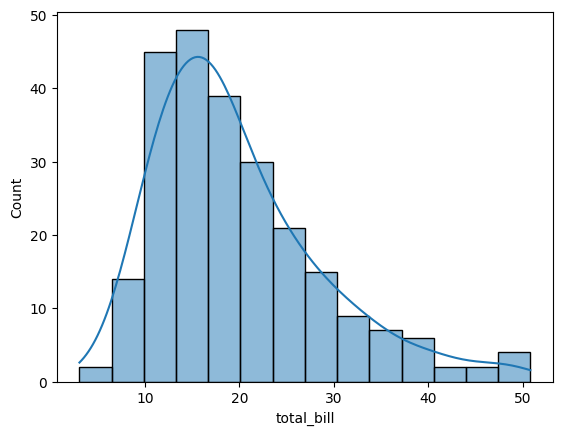

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
sns.histplot(tips["total_bill"], kde=True)
plt.show()

## Label Encoding

In [1]:
import pandas as pd

df = pd.DataFrame({'City': ['Mumbai','Pune','Delhi','Mumbai']})

encoded = pd.get_dummies(df, columns=['City'], dtype=int)
print(encoded)


   City_Delhi  City_Mumbai  City_Pune
0           0            1          0
1           0            0          1
2           1            0          0
3           0            1          0


In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['City_Encoded'] = le.fit_transform(df['City'])


In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
edu_map = {'School': 1, 'Graduate': 2, 'Post Graduate': 3}



df['Education'] = ['Graduate', 'School', 'Post Graduate', 'Graduate']

df['Education_Encoded'] = df['Education'].map(edu_map)

## Feature Engineering

In [6]:
import pandas as pd




marks  = [28, 45, 67, 82]
bins   = [0, 40, 60, 80, 100]
labels = ['Poor', 'Average', 'Good', 'Excellent']

df['Grade'] = pd.cut(marks, bins=bins, labels=labels)




Grade


In [ ]:
import numpy as np



df['salary'] = [50000, 60000, 75000, 55000]

df['log_salary'] = np.log(df['salary'])

In [ ]:
import numpy as np



df['feature'] = [10, 20, 30, 40]

df['sqrt_feature'] = np.sqrt(df['feature'])

In [ ]:
import pandas as pd



df['date'] = pd.to_datetime(['2023-01-01', '2023-01-02', '2023-01-03', '2023-01-04'])

df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['day']     = df['date'].dt.day
df['weekday'] = df['date'].dt.day_name()

##OUTLIER DETECTION

In [ ]:
Q1  = df['salary'].quantile(0.25)
Q3  = df['salary'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['salary'] < lower) | (df['salary'] > upper)]

## Data Cleaning and Inspection Demonstrations

In [ ]:
import pandas as pd
import numpy as np


data = {
    'Age': [25, 30, np.nan, 25, 40, 35, np.nan, 50],
    'Salary': [50000, 60000, 75000, 50000, np.nan, 65000, 80000, 90000],
    'City': ['Mumbai', 'Pune', 'Delhi', 'Mumbai', 'Bangalore', 'Pune', np.nan, 'Chennai'],
    'Experience': [2, 5, 10, 2, 15, 8, 12, np.nan],
    'Passport_Number': ['P1', 'P2', 'P3', 'P1', 'P4', np.nan, 'P6', 'P7']
}

df_clean_demo = pd.DataFrame(data)
print("Original DataFrame with NaNs and Duplicates:")
display(df_clean_demo)


Original DataFrame with NaNs and Duplicates:


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,NaN,75000.0,Delhi,10.0,P3
3,25.0,50000.0,Mumbai,2.0,P1
4,40.0,NaN,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,NaN
6,NaN,80000.0,NaN,12.0,P6
7,50.0,90000.0,Chennai,NaN,P7


### Check for Missing Values: `df.isnull().sum()`

In [ ]:
print("Missing values per column:")
display(df_clean_demo.isnull().sum())


Missing values per column:


,0
Age,2
Salary,1
City,1
Experience,1
Passport_Number,1


###  Impute Missing Values: `fillna()`

In [ ]:

df_imputed_mean = df_clean_demo.copy()


df_imputed_mean['Age'].fillna(df_imputed_mean['Age'].mean(), inplace=True)
print("DataFrame after mean imputation for 'Age':")
display(df_imputed_mean.isnull().sum())
display(df_imputed_mean)


DataFrame after mean imputation for 'Age':


/tmp/ipykernel_15842/2449713106.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['Age'].fillna(df_imputed_mean['Age'].mean(), inplace=True)


,0
Age,0
Salary,1
City,1
Experience,1
Passport_Number,1


,Age,Salary,City,Experience,Passport_Number
0,25.000000,50000.0,Mumbai,2.0,P1
1,30.000000,60000.0,Pune,5.0,P2
2,34.166667,75000.0,Delhi,10.0,P3
3,25.000000,50000.0,Mumbai,2.0,P1
4,40.000000,NaN,Bangalore,15.0,P4
5,35.000000,65000.0,Pune,8.0,NaN
6,34.166667,80000.0,NaN,12.0,P6
7,50.000000,90000.0,Chennai,NaN,P7


In [ ]:

df_imputed_median = df_clean_demo.copy()


df_imputed_median['Salary'].fillna(df_imputed_median['Salary'].median(), inplace=True)
print("DataFrame after median imputation for 'Salary':")
display(df_imputed_median.isnull().sum())
display(df_imputed_median)


DataFrame after median imputation for 'Salary':


/tmp/ipykernel_15842/318537827.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_median['Salary'].fillna(df_imputed_median['Salary'].median(), inplace=True)


,0
Age,2
Salary,0
City,1
Experience,1
Passport_Number,1


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,NaN,75000.0,Delhi,10.0,P3
3,25.0,50000.0,Mumbai,2.0,P1
4,40.0,65000.0,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,NaN
6,NaN,80000.0,NaN,12.0,P6
7,50.0,90000.0,Chennai,NaN,P7


In [ ]:

df_imputed_mode = df_clean_demo.copy()


df_imputed_mode['City'].fillna(df_imputed_mode['City'].mode()[0], inplace=True)
print("DataFrame after mode imputation for 'City':")
display(df_imputed_mode.isnull().sum())
display(df_imputed_mode)


DataFrame after mode imputation for 'City':


/tmp/ipykernel_15842/1012340673.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mode['City'].fillna(df_imputed_mode['City'].mode()[0], inplace=True)


,0
Age,2
Salary,1
City,0
Experience,1
Passport_Number,1


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,NaN,75000.0,Delhi,10.0,P3
3,25.0,50000.0,Mumbai,2.0,P1
4,40.0,NaN,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,NaN
6,NaN,80000.0,Mumbai,12.0,P6
7,50.0,90000.0,Chennai,NaN,P7


In [ ]:

df_ffill_bfill = df_clean_demo.copy()


df_ffill_bfill['Experience'].fillna(method='ffill', inplace=True)
print("DataFrame after forward fill (ffill) for 'Experience':")
display(df_ffill_bfill.isnull().sum())
display(df_ffill_bfill)


DataFrame after forward fill (ffill) for 'Experience':


/tmp/ipykernel_15842/1108217957.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_ffill_bfill['Experience'].fillna(method='ffill', inplace=True)
/tmp/ipykernel_15842/1108217957.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill_bfill['Experience'].fillna(method='ffill', inplace=True)


,0
Age,2
Salary,1
City,1
Experience,0
Passport_Number,1


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,NaN,75000.0,Delhi,10.0,P3
3,25.0,50000.0,Mumbai,2.0,P1
4,40.0,NaN,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,NaN
6,NaN,80000.0,NaN,12.0,P6
7,50.0,90000.0,Chennai,12.0,P7


In [ ]:

df_bfill_demo = df_clean_demo.copy()


df_bfill_demo.fillna(method='bfill', inplace=True)
print("DataFrame after backward fill (bfill) for all columns:")
display(df_bfill_demo.isnull().sum())
display(df_bfill_demo)


DataFrame after backward fill (bfill) for all columns:


/tmp/ipykernel_15842/793528988.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill_demo.fillna(method='bfill', inplace=True) # Applies to all columns


,0
Age,0
Salary,0
City,0
Experience,1
Passport_Number,0


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,25.0,75000.0,Delhi,10.0,P3
3,25.0,50000.0,Mumbai,2.0,P1
4,40.0,65000.0,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,P6
6,50.0,80000.0,Chennai,12.0,P6
7,50.0,90000.0,Chennai,NaN,P7


###  KNN Imputation

In [ ]:
from sklearn.impute import KNNImputer



df_knn_demo = df_clean_demo[['Age', 'Salary', 'Experience']].copy()

imputer = KNNImputer(n_neighbors=2)
df_imputed_knn = imputer.fit_transform(df_knn_demo)


df_imputed_knn = pd.DataFrame(df_imputed_knn, columns=['Age', 'Salary', 'Experience'])
print("DataFrame after KNN imputation (on numerical columns):")
display(df_imputed_knn.isnull().sum())
display(df_imputed_knn)


DataFrame after KNN imputation (on numerical columns):


,0
Age,0
Salary,0
Experience,0


,Age,Salary,Experience
0,25.0,50000.0,2.0
1,30.0,60000.0,5.0
2,37.5,75000.0,10.0
3,25.0,50000.0,2.0
4,40.0,77500.0,15.0
5,35.0,65000.0,8.0
6,45.0,80000.0,12.0
7,50.0,90000.0,13.5


###  Drop Rows with Missing Values: `df.dropna()`

In [ ]:
df_dropna_demo = df_clean_demo.copy()
df_dropna_demo.dropna(inplace=True)
print("DataFrame after dropping rows with any missing values:")
display(df_dropna_demo.isnull().sum())
display(df_dropna_demo)


DataFrame after dropping rows with any missing values:


,0
Age,0
Salary,0
City,0
Experience,0
Passport_Number,0


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
3,25.0,50000.0,Mumbai,2.0,P1


###  Drop Columns: `df.drop(columns=[...])`

In [ ]:
df_drop_col_demo = df_clean_demo.copy()

df_drop_col_demo.drop(columns=["Passport_Number"], inplace=True)
print("DataFrame after dropping 'Passport_Number' column:")
display(df_drop_col_demo)


DataFrame after dropping 'Passport_Number' column:


,Age,Salary,City,Experience
0,25.0,50000.0,Mumbai,2.0
1,30.0,60000.0,Pune,5.0
2,NaN,75000.0,Delhi,10.0
3,25.0,50000.0,Mumbai,2.0
4,40.0,NaN,Bangalore,15.0
5,35.0,65000.0,Pune,8.0
6,NaN,80000.0,NaN,12.0
7,50.0,90000.0,Chennai,NaN


###  Check for Duplicates: `df.duplicated().sum()`

In [ ]:
print("Number of duplicate rows (excluding first occurrence):")
display(df_clean_demo.duplicated().sum())

print("Original DataFrame showing duplicate rows:")
display(df_clean_demo[df_clean_demo.duplicated(keep=False)])


df_no_duplicates = df_clean_demo.drop_duplicates().copy()
print("DataFrame after removing duplicate rows:")
display(df_no_duplicates)


Number of duplicate rows (excluding first occurrence):


np.int64(1)

Original DataFrame showing duplicate rows:


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
3,25.0,50000.0,Mumbai,2.0,P1


DataFrame after removing duplicate rows:


,Age,Salary,City,Experience,Passport_Number
0,25.0,50000.0,Mumbai,2.0,P1
1,30.0,60000.0,Pune,5.0,P2
2,NaN,75000.0,Delhi,10.0,P3
4,40.0,NaN,Bangalore,15.0,P4
5,35.0,65000.0,Pune,8.0,NaN
6,NaN,80000.0,NaN,12.0,P6
7,50.0,90000.0,Chennai,NaN,P7


###  Get DataFrame Information: `df.info()`

In [ ]:
print("DataFrame Info:")
df_clean_demo.info()


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              6 non-null      float64
 1   Salary           7 non-null      float64
 2   City             7 non-null      object 
 3   Experience       7 non-null      float64
 4   Passport_Number  7 non-null      object 
dtypes: float64(3), object(2)
memory usage: 452.0+ bytes


### Get Descriptive Statistics: `df.describe()`

In [ ]:
print("Descriptive statistics for numerical columns:")
display(df_clean_demo.describe())


Descriptive statistics for numerical columns:


,Age,Salary,Experience
count,6.000000,7.000000,7.000000
mean,34.166667,67142.857143,7.714286
std,9.703951,15236.235006,4.990467
min,25.000000,50000.000000,2.000000
25%,26.250000,55000.000000,3.500000
50%,32.500000,65000.000000,8.000000
75%,38.750000,77500.000000,11.000000
max,50.000000,90000.000000,15.000000
